In [300]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import plotly.express as px


### Read data

In [301]:
df = pd.read_csv('input/tsne.csv')
df

,branch,sales,sales_area,n_employee,n_transactions,footfall,n_employee_left
0,a,25000,950,95,550,1000,10
1,b,25000,900,100,530,1010,10
2,c,25000,980,97,520,1000,8
3,d,22000,990,90,500,1000,10
4,e,5000,400,30,50,70,8
5,f,6000,500,35,60,70,10
6,g,11000,500,60,150,610,8
7,h,12000,530,62,120,650,10
8,i,11500,520,65,130,630,8
9,j,11700,500,63,145,640,10


### Metrics

In [302]:
df['sales_m2'] = df['sales']/df['sales_area']
df['sales_empl'] = df['sales']/df['n_employee']
df['foot_trans'] = df['footfall']/df['n_transactions']

df

,branch,sales,sales_area,n_employee,n_transactions,footfall,n_employee_left,sales_m2,sales_empl,foot_trans
0,a,25000,950,95,550,1000,10,26.315789,263.157895,1.818182
1,b,25000,900,100,530,1010,10,27.777778,250.000000,1.905660
2,c,25000,980,97,520,1000,8,25.510204,257.731959,1.923077
3,d,22000,990,90,500,1000,10,22.222222,244.444444,2.000000
4,e,5000,400,30,50,70,8,12.500000,166.666667,1.400000
5,f,6000,500,35,60,70,10,12.000000,171.428571,1.166667
6,g,11000,500,60,150,610,8,22.000000,183.333333,4.066667
7,h,12000,530,62,120,650,10,22.641509,193.548387,5.416667
8,i,11500,520,65,130,630,8,22.115385,176.923077,4.846154
9,j,11700,500,63,145,640,10,23.400000,185.714286,4.413793


### Choose metrics

In [303]:
X = df[['sales_m2', 
        'sales_empl', 
        'foot_trans', 
        'n_employee_left'
        ]].copy()
X

,sales_m2,sales_empl,foot_trans,n_employee_left
0,26.315789,263.157895,1.818182,10
1,27.777778,250.000000,1.905660,10
2,25.510204,257.731959,1.923077,8
3,22.222222,244.444444,2.000000,10
4,12.500000,166.666667,1.400000,8
5,12.000000,171.428571,1.166667,10
6,22.000000,183.333333,4.066667,8
7,22.641509,193.548387,5.416667,10
8,22.115385,176.923077,4.846154,8
9,23.400000,185.714286,4.413793,10


### Choose valid metrics

In [304]:
''' 
Choose just those which have variability!!!!

'''

' \nChoose just those which have variability!!!!\n\n'

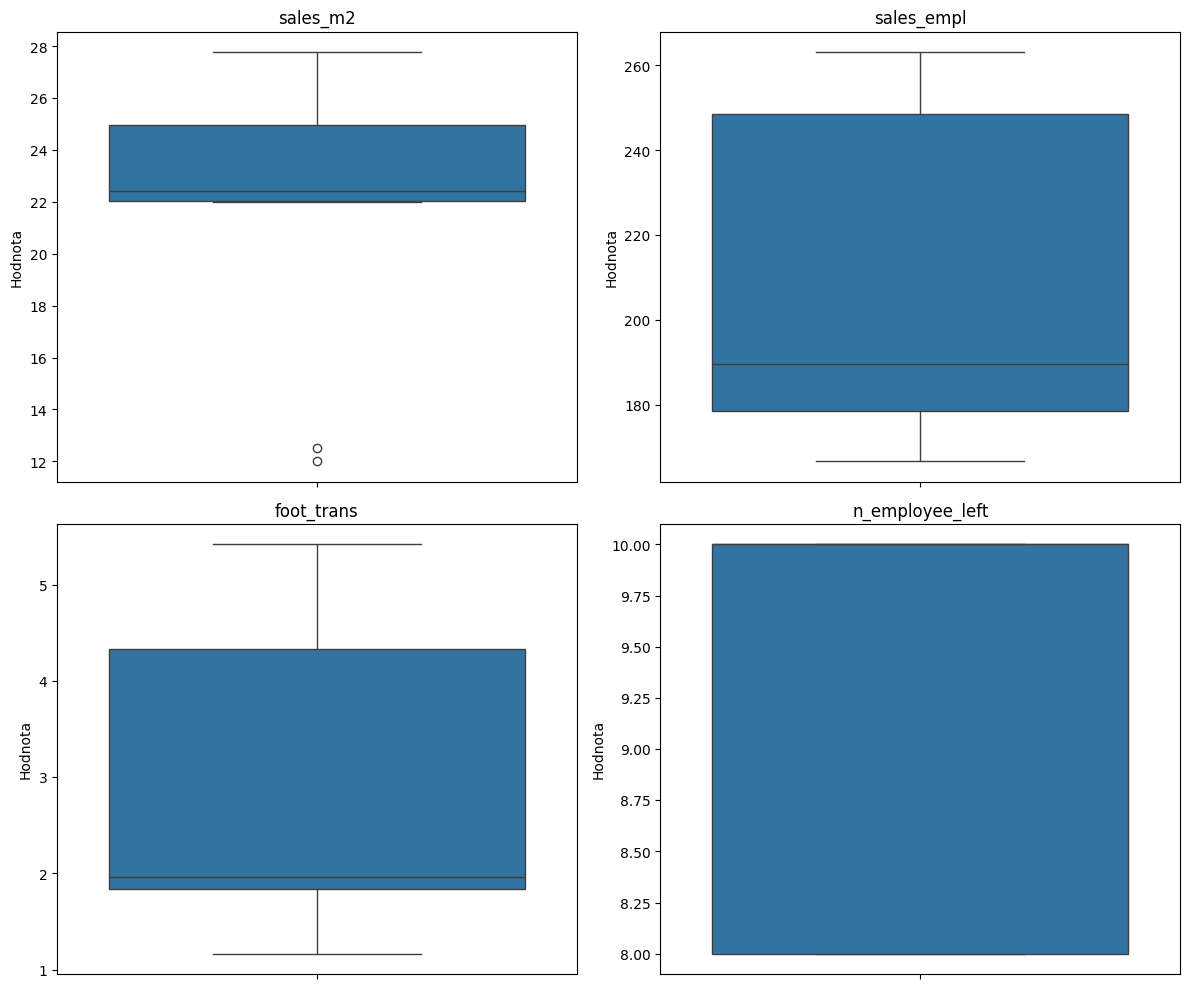

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# X je tvůj DataFrame a všechny sloupce jsou číselné
X_numeric = X.astype(float)

# Vybereme první 4 metriky pro 2x2 grid
metrics = X_numeric.columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid
axes = axes.flatten()  # usnadní iteraci

for i, col in enumerate(metrics):
    sns.boxplot(y=X_numeric[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Hodnota")

plt.tight_layout()
plt.show()

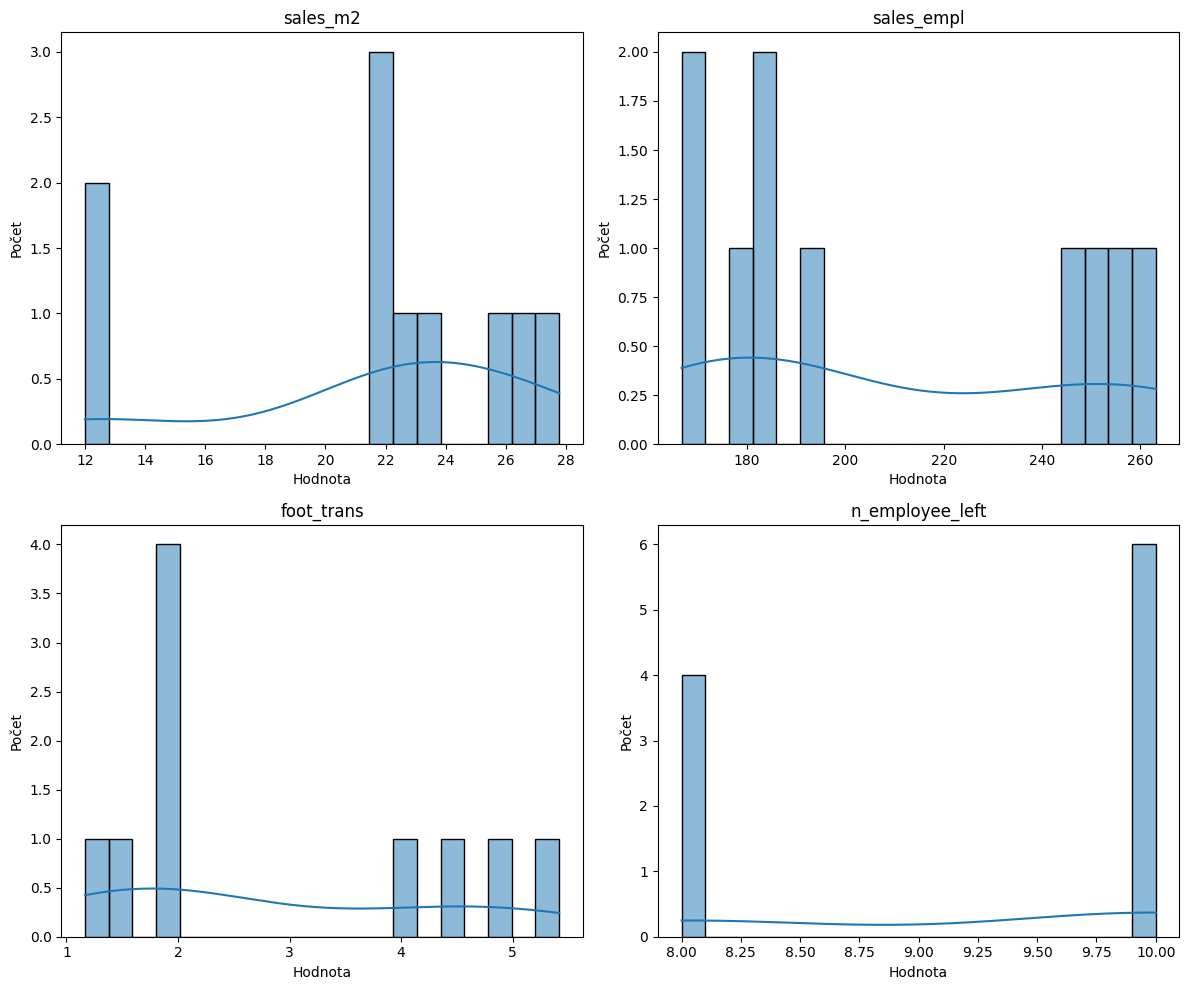

In [306]:
# X je tvůj DataFrame, všechny sloupce číselné
X_numeric = X.astype(float)

# Vybereme první 4 metriky pro 2x2 grid
metrics = X_numeric.columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # usnadní iteraci

for i, col in enumerate(metrics):
    sns.histplot(X_numeric[col], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel("Hodnota")
    axes[i].set_ylabel("Počet")

plt.tight_layout()
plt.show()


### Normalize

In [307]:
X = df[['sales_m2', 
        'sales_empl', 
        'foot_trans', 
        #'n_employee_left'
        ]].copy()
X

,sales_m2,sales_empl,foot_trans
0,26.315789,263.157895,1.818182
1,27.777778,250.000000,1.905660
2,25.510204,257.731959,1.923077
3,22.222222,244.444444,2.000000
4,12.500000,166.666667,1.400000
5,12.000000,171.428571,1.166667
6,22.000000,183.333333,4.066667
7,22.641509,193.548387,5.416667
8,22.115385,176.923077,4.846154
9,23.400000,185.714286,4.413793


In [308]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.92289696,  1.44385054, -0.71123613],
       [ 1.21197341,  1.09114049, -0.65349354],
       [ 0.76360993,  1.2984031 , -0.64199728],
       [ 0.11348289,  0.94221846, -0.59122213],
       [-1.80887554, -1.14268989, -0.98726833],
       [-1.90773969, -1.01504244, -1.14128629],
       [ 0.06954326, -0.69592381,  0.772937  ],
       [ 0.19638783, -0.42209944,  1.66404095],
       [ 0.09235807, -0.86775692,  1.28745856],
       [ 0.34636288, -0.63210009,  1.00206718]])

### T-SNE before clustering

In [309]:
''' 
Play with perplexity.

'''

' \nPlay with perplexity.\n\n'

In [310]:
# t-SNE redukce do 2D
tsne_01 = TSNE(n_components=2, perplexity=2, random_state=42)
X_tsne_01 = tsne_01.fit_transform(X_scaled)



# t-SNE redukce do 2D
tsne_02 = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne_02 = tsne_02.fit_transform(X_scaled)

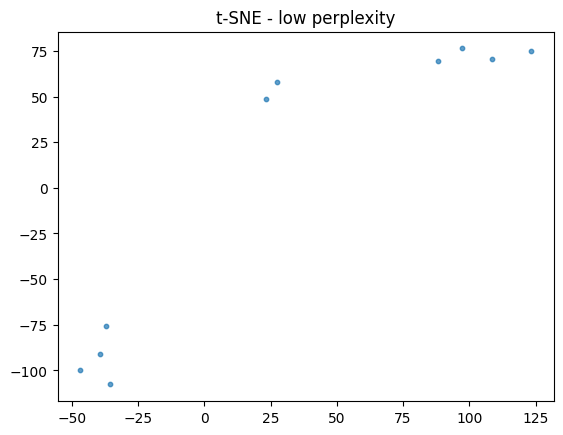

In [311]:
# vizualizace
plt.scatter(X_tsne_01[:, 0], X_tsne_01[:, 1], s=10, alpha=0.7)
plt.title("t-SNE - low perplexity")
plt.show()

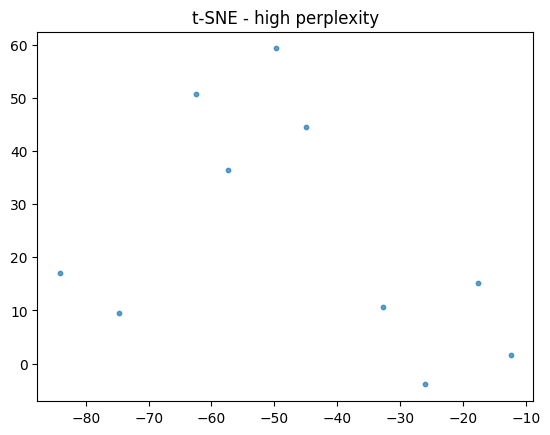

In [312]:
# vizualizace
plt.scatter(X_tsne_02[:, 0], X_tsne_02[:, 1], s=10, alpha=0.7)
plt.title("t-SNE - high perplexity")
plt.show()

In [313]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def hopkins(X, m=None):
    if m is None:
        m = int(0.1 * X.shape[0])  # 10 % vzorků
    d = X.shape[1]
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_X = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))
    u_dist, _ = nbrs.kneighbors(rand_X)
    w_dist, _ = nbrs.kneighbors(X[np.random.choice(X.shape[0], m, replace=False)])
    return u_dist.sum() / (u_dist.sum() + w_dist.sum())

hopkins_score = hopkins(X_scaled)
print("Hopkins statistic:", hopkins_score)


Hopkins statistic: 1.0


### Clustering

In [315]:
# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['cluster'] = labels
print(df[['branch', 'sales_m2', 'sales_empl', 'foot_trans', 'cluster']])

  branch   sales_m2  sales_empl  foot_trans  cluster
0      a  26.315789  263.157895    1.818182        0
1      b  27.777778  250.000000    1.905660        0
2      c  25.510204  257.731959    1.923077        0
3      d  22.222222  244.444444    2.000000        0
4      e  12.500000  166.666667    1.400000        2
5      f  12.000000  171.428571    1.166667        2
6      g  22.000000  183.333333    4.066667        1
7      h  22.641509  193.548387    5.416667        1
8      i  22.115385  176.923077    4.846154        1
9      j  23.400000  185.714286    4.413793        1


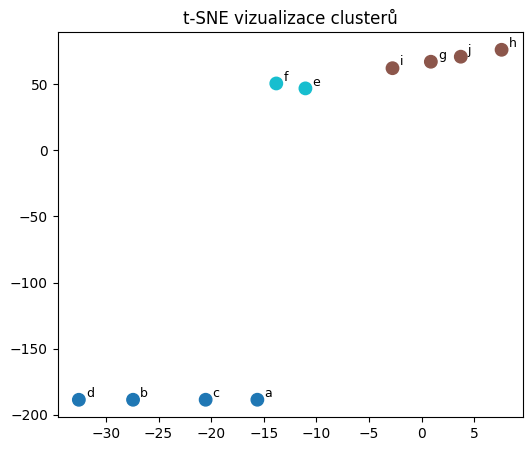

In [318]:
# t-SNE redukce na 2D
tsne = TSNE(n_components=2, perplexity=2, random_state=42)  # malý dataset → nižší perplexity
X_tsne = tsne.fit_transform(X)

# vizualizace
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['cluster'], cmap='tab10', s=80)

# přidáme popisky poboček
for i, txt in enumerate(df['branch']):
    plt.annotate(txt, (X_tsne[i,0], X_tsne[i,1]), fontsize=9, xytext=(5,2), textcoords='offset points')

plt.title("t-SNE vizualizace clusterů")
plt.show()

In [317]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.823
k=3, silhouette=0.666
k=4, silhouette=0.472
k=5, silhouette=0.461
